In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [31]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next
def build_dataset(words):
    X, Y = [], []
    for w in words: 
        context = [0] * block_size
        for ch in w + '.': # for each character plus an end token
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])        # 80%
Xdev, Ydev = build_dataset(words[n1:n2])    # 10%
Xte, Yte = build_dataset(words[n2:])        # 10%

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [ ]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g) 
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * (5/3) / ((block_size*n_embd)**0.5)
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

# BN parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # embed the characters into vectors, shape (batch_size, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors together, shape (batch_size, block_size*n_embd)
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation, shape (batch_size, n_hidden)
    
    # 经过 BN 后，b1 实际上已经没有什么意义了，BN 会把它的效果抵消掉
    # 换句话说，BN 的仿射变换参数 bnbias 已经承担了偏置的作用，b1 可以被视为冗余的参数

    # batch normalization
    # --------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)

    hpreact = hpreact * (hpreact - bnmeani) / (bnstdi + 1e-5) + bnbias # batch norm  
    
    with torch.no_grad():
        # 传入单样本的方法二：训练时更新 BN 统计量的 running mean 和 running std
        # 用于 test 时的单样本预测
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
        # 大 batch size 用大的 momentum，反之用小的 momentum，来平衡当前 batch 统计量和历史统计量的权重

    # 为什么需要仿射变换？防止高斯化丧失模型表达能力

    # BN 的 SIDE EFFECT
    # BN 带来了样本之间的耦合 Coupling，破坏了样本间的独立性
    # 每个Batch 的均值和标准差会因为批次里训练样本的不同而 jitter
    # 但这反而带来了数据增强或者说正则化的效果
    # 通过引入随机噪声，让模型不至于过拟合训练数据，迫使神经网络去学习数据中真正稳健、泛化能力强的模式
    # --------------------------------

    h = torch.tanh(hpreact) # hidden layer activation, shape (batch_size, n_hidden)
    logits = h @ W2 + b2 # output layer pre-activation (logits), shape (batch_size, vocab_size)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.item())
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    #break

      0/ 200000: 3.2959
  10000/ 200000: 2.2364
  20000/ 200000: 2.0681
  30000/ 200000: 2.0490
  40000/ 200000: 2.6108
  50000/ 200000: 1.7969
  60000/ 200000: 2.3922
  70000/ 200000: 2.2939
  80000/ 200000: 2.3323
  90000/ 200000: 1.6915
 100000/ 200000: 2.2595
 110000/ 200000: 2.1480
 120000/ 200000: 1.8747
 130000/ 200000: 2.1480
 140000/ 200000: 1.8141
 150000/ 200000: 2.0055
 160000/ 200000: 2.2493
 170000/ 200000: 2.0425
 180000/ 200000: 2.0000
 190000/ 200000: 1.7093


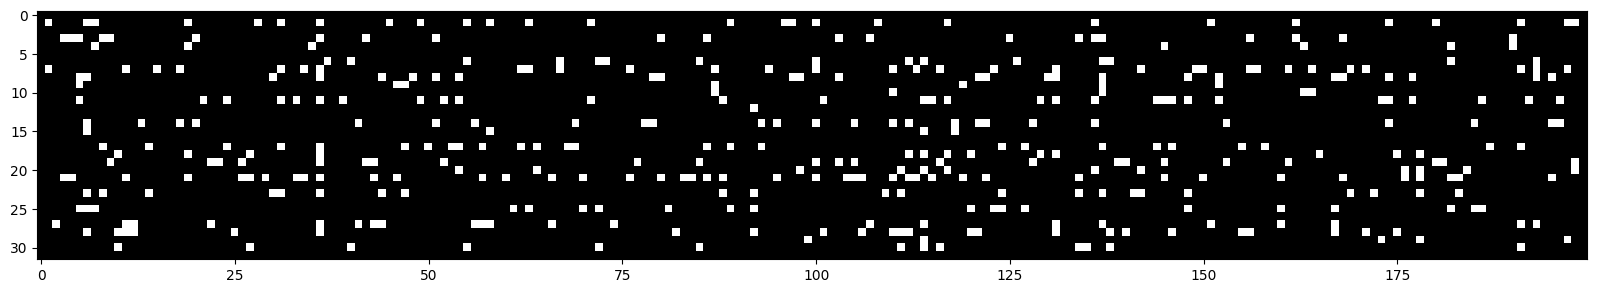

In [34]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

(array([454., 202., 172., 141., 121., 111.,  80.,  81., 102., 107.,  99.,
         83., 108.,  74., 139., 100.,  87., 101., 105., 124., 107., 139.,
        126., 150., 190., 137., 127., 120., 150., 110., 143.,  83.,  96.,
         81., 118., 113.,  91.,  75.,  84.,  96., 110.,  78.,  97.,  97.,
         86., 111., 116., 128., 211., 439.]),
 array([-9.99985754e-01, -9.59986064e-01, -9.19986374e-01, -8.79986684e-01,
        -8.39986994e-01, -7.99987304e-01, -7.59987614e-01, -7.19987924e-01,
        -6.79988234e-01, -6.39988544e-01, -5.99988854e-01, -5.59989164e-01,
        -5.19989474e-01, -4.79989784e-01, -4.39990094e-01, -3.99990404e-01,
        -3.59990714e-01, -3.19991024e-01, -2.79991333e-01, -2.39991643e-01,
        -1.99991953e-01, -1.59992263e-01, -1.19992573e-01, -7.99928832e-02,
        -3.99931931e-02,  6.49690628e-06,  4.00061870e-02,  8.00058770e-02,
         1.20005567e-01,  1.60005257e-01,  2.00004947e-01,  2.40004637e-01,
         2.80004327e-01,  3.20004017e-01,  3.60003

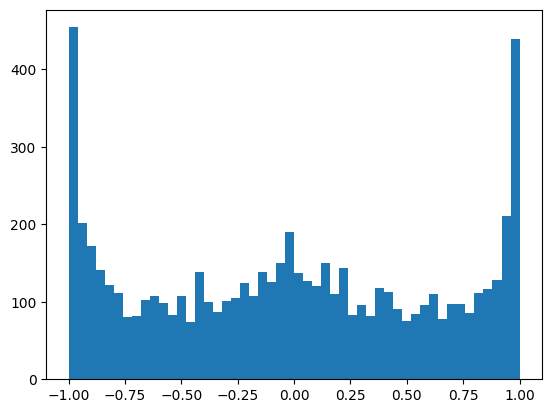

In [35]:
plt.hist(h.view(-1).tolist(), 50)

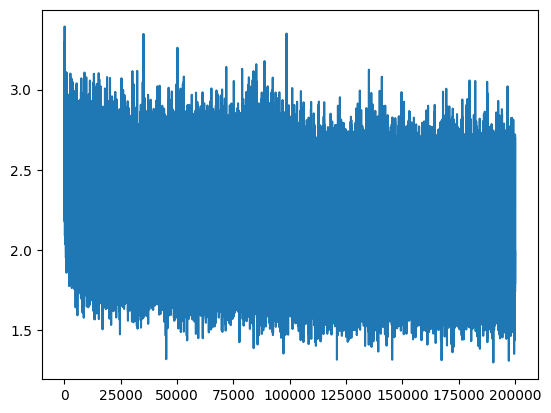

In [36]:
plt.plot(lossi)

In [ ]:
# BN 支持传单样本的做法一：训练完后计算训练集的均值和方差
# 测试时算好训练集的 BN 统计量
# 使得可以只传入一个样本进行预测
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (num_examples, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (num_examples, block_size*n_embd)
    hpreact = embcat @ W1 + b1 # (num_examples, n_hidden)
    # hpreact = (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) # batch norm  
    # hpreact = hpreact * bngain + bnbias # scale and shift
    hpreact = (hpreact - bnmean_running) / (bnstd_running + 1e-5) * bngain + bnbias # use the training set statistics for normalization
    
    h = torch.tanh(hpreact) # (num_examples, n_hidden)
    logits = h @ W2 + b2 # (num_examples, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')

NameError: name 'bnmean_running' is not defined

In [1]:
# ---------------- Summary

In [ ]:
class BatchNorm1d:
    def __init__(self, dim, training=True, epsilon=1e-5, momentum=0.1):
        self.dim = dim
        self.training = training
        self.epsilon = epsilon
        self.momentum = momentum
        # affine params
        self.gamma = torch.ones(1, self.dim)
        self.beta = torch.zeros(1, self.dim)
        # buffers (no grad)
        self.running_mean = torch.zeros(1, self.dim)
        self.running_var = torch.ones(1, self.dim)

        # 缺少注册 requires_grad
        # ...
        
    def __call__(self, x):
        if self.training:
            meani = x.mean(0, keepdim=True)
            vari = x.var(0, keepdim=True, correction=0)    
            with torch.no_grad():
                # EMA
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * meani
                vari_corr1 = x.var(0, keepdim=True, correction=1) 
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * vari_corr1
        else:
            meani = self.running_mean
            vari = self.running_var
        out = ((x - meani) / torch.sqrt(vari + self.epsilon)) * self.gamma + self.beta
            
        return out

